# Machine Learning and Statistical Testing

This notebook walks through **one research question** from start to finish, and uses the **same model** (linear regression) in two ways:

1. **Statistics** (`statsmodels`): *testing* hypotheses. Is there a significant effect?
2. **Machine Learning** (`scikit-learn`): *predicting*. How many pages will a new visitor view?

| Step | What we do |
|---|---|
| The case | research question, hypotheses and the variables we need |
| Load and prepare | load the data and build the variables |
| Explore | compare the groups before modelling |
| Statistics | test the hypotheses with OLS |
| Machine Learning | predict pageviews with the same model |
| Interpretation | answer the hypotheses |
| Wrap-up | two uses of one model |
| Your turn | repeat the example for a different outcome |

In [56]:
import pandas as pd
import seaborn as sns
%matplotlib inline

In [57]:
pd.set_option('display.precision', 2)   # show all pandas numbers with 2 decimals

Now let's import the two packages we'll use for statistical testing (statsmodels) and machine learning (sklearn):

In [58]:
from sklearn.linear_model import LogisticRegression, LinearRegression
import statsmodels.api as sm

#### Note: the new packages

**Why this step:** we use the same model for two goals, so we need two packages: one for **testing hypotheses** (statsmodels) and one for **making predictions** (sklearn).

If you do not have these packages (i.e., you receive an ```ImportError``` message), run:

In [59]:
# ! pip install scikit-learn statsmodels

## The case (from the tutorial)
Our website has launched two new campaigns, **CPC** (paid ads) and **affiliate** (partner websites), to increase engagement. Here, engagement means that visitors see more pages (`totals_pageviews`).

**RQ:** To what extent have the new campaigns increased the number of pages visitors view, compared to other referrals to the website?

Hypotheses:
* *H1a.* Users entering the website via the affiliate campaign will visualize more pages (total pageviews) compared to users entering from non-campaign referrals.
* *H1b.* Users entering the website via the CPC campaign will visualize more pages (total pageviews) compared to users entering from non-campaign referrals.

We also want to check whether owning an Apple device and being in the US influence pageviews.

### What do I need to do with my data?

* One variable for pageviews (DV)
* One variable indicating whether the referral was a CPC campaign (IV)
* One variable indicating whether the referral was an affiliate campaign (IV)
* Two control variables: Apple device, and location (US)



| Role | Meaning | Column we will build |
|---|---|---|
| **DV** (dependent variable) | the outcome we want to explain | `pageviews` |
| **IV** (independent variable) | the variables whose effect we test | `cpc`, `affiliate` (1 = came via this campaign) |
| **Control** | variables we add so their effect is not mixed up with the IVs | `apple_device`, `country_US` |

Visitors who came neither via CPC nor via affiliate are the **reference group**: every campaign effect is measured against them. Controls matter because campaigns are not shown randomly: if CPC ads mostly reach countries where people browse less, part of the "CPC effect" would really be a country effect.

## Loading data

In [60]:
data = pd.read_csv('../da5_data/googlestore.csv')

/var/folders/y_/81kq7b1d6v186rxnhwbtxybm0000gn/T/ipykernel_70435/2838002746.py:1: DtypeWarning: Columns (6: fullVisitorId) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('../da5_data/googlestore.csv')
Task was destroyed but it is pending!
task: <Task pending name='Task-384' coro=<_async_in_context.<locals>.run_in_context() done, defined at /Users/ednew/Library/jupyterlab-desktop/jlab_server/lib/python3.12/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-385' coro=<Kernel.shell_main() running at /Users/ednew/Library/jupyterlab-desktop/jlab_server/lib/python3.12/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /Users/ednew/Library/jupyterlab-desktop/jlab_server/lib/python3.12/site-packages/zmq/eventloop/zmqstream.py:563]>
/Users/ednew/Library/jupyterlab-desktop/jlab_server/lib/python3.12/site-packages/pandas/core/internals/managers.py:2451: Runtime

In [61]:
data.head(2)

,channelGrouping,date,device_browser,device_deviceCategory,device_isMobile,device_operatingSystem,fullVisitorId,geoNetwork_city,geoNetwork_continent,geoNetwork_country,...,trafficSource_adwordsClickInfo_slot,trafficSource_campaign,trafficSource_isTrueDirect,trafficSource_keyword,trafficSource_medium,trafficSource_referralPath,trafficSource_source,visitId,visitNumber,visitStartTime
0,Referral,20171001,Chrome,desktop,False,Macintosh,9460190543836614586,NaN,Americas,United States,...,NaN,(not set),NaN,NaN,(none),/,(direct),1506841168,1,1506841201
1,Paid Search,20171001,Chrome,desktop,False,Macintosh,1480173241963500874,NaN,Americas,United States,...,Top,AW - Dynamic Search Ads Whole Site,NaN,6qEhsCssdK0z36ri,cpc,NaN,google,1506841096,1,1506841214


In [62]:
len(data)

52308

In [63]:
# Lets work on sampled data instead of running on all the row
data = data.sample(frac=0.15, random_state=42)
# what will happen if u omit random_state

#### Note: working with a sample

**Why this step:** the full dataset (52,308 visits) makes some steps slow, especially the functions that go through the data value by value. A random sample keeps the same patterns and runs faster.

**Breaking down `data.sample(frac=0.15, random_state=42)`:**
- `frac=0.15`: keep a random 15% of the rows
- `random_state=42`: fixes the randomness, so everyone gets the same 15% every time and the results are reproducible

In [64]:
len(data)

7846

Inspecting the dataset

In [65]:
# Lets check for the missing value 
data[['device_operatingSystem', 'geoNetwork_country', 'totals_pageviews', 'trafficSource_medium']].isna().sum()

device_operatingSystem    0
geoNetwork_country        0
totals_pageviews          0
trafficSource_medium      0
dtype: int64

In [66]:
# Lets check the distribution of sources from 'trafficSource_medium' column
data['trafficSource_medium'].value_counts()

trafficSource_medium
organic      3455
cpc          1981
(none)       1467
referral      808
affiliate      99
cpm            36
Name: count, dtype: int64

## Preparing the variables

Here we build the DV, the two IVs and the two controls from step *What do I need to do with my data?*. You have seen more about these steps in DA3.

In [67]:
data.columns

Index(['channelGrouping', 'date', 'device_browser', 'device_deviceCategory',
       'device_isMobile', 'device_operatingSystem', 'fullVisitorId',
       'geoNetwork_city', 'geoNetwork_continent', 'geoNetwork_country',
       'geoNetwork_metro', 'geoNetwork_networkDomain', 'geoNetwork_region',
       'geoNetwork_subContinent', 'landing_appInfo_landingScreenName',
       'landing_appInfo_screenDepth', 'landing_appInfo_screenName',
       'landing_contentGroup_contentGroup1',
       'landing_contentGroup_contentGroup2',
       'landing_contentGroup_contentGroup3',
       'landing_contentGroup_contentGroup4',
       'landing_contentGroup_contentGroup5', 'landing_hour',
       'landing_isEntrance', 'landing_isExit', 'landing_minute',
       'landing_page_hostname', 'landing_page_pagePath',
       'landing_page_pagePathLevel1', 'landing_page_pagePathLevel2',
       'landing_page_pagePathLevel3', 'landing_page_pagePathLevel4',
       'landing_page_pageTitle', 'landing_product_isClick',
      

In [13]:
# keep only the columns we need to build our variables
data = data[['totals_pageviews',        # DV: pageviews
             'trafficSource_medium',    # IVs: cpc, affiliate
             'device_operatingSystem',  # control: apple_device
             'geoNetwork_country',      # control: country_US
             'landing_isExit']]         # needed in the exercise (bounce)
data.head()

,totals_pageviews,trafficSource_medium,device_operatingSystem,geoNetwork_country,landing_isExit
36548,3.0,(none),Macintosh,United States,NaN
26376,2.0,cpc,Android,United States,NaN
21940,47.0,organic,Macintosh,Mexico,NaN
8907,5.0,organic,Android,Italy,NaN
36441,1.0,(none),Linux,United States,True


In [68]:
data['totals_pageviews'].describe()

count    7846.00
mean        3.20
std         5.38
min         1.00
25%         1.00
50%         1.00
75%         3.00
max        81.00
Name: totals_pageviews, dtype: float64

#### Note: a skewed variable

**What you should see:** a median (50%) of 1 page but a mean of 3.2 and a maximum of 81: most visits see only one page, and a few very long visits pull the mean up. This helps to read the OLS results later.

In [69]:
data['pageviews'] = data['totals_pageviews'].fillna(0)

#### Note: filling missing values

A regression cannot use rows with missing values, so the DV must be complete. In this sample it changes nothing: the inspection above showed **no missing values** in `totals_pageviews`. The line is there as a safety step, and it creates the column `pageviews` that we use in the model.

We want to understand if campaigns from affiliates or using cpc are performing better than other ways that visitors have to get to the site.

In [70]:
def check_category(source, variablename):
    if source == variablename:
        return 1
    return 0

In [71]:
# Converting the text values into a '0' and '1'
data['cpc'] = data['trafficSource_medium'].apply(check_category, args=('cpc',))
data['affiliate'] = data['trafficSource_medium'].apply(check_category, args=('affiliate',))

In [72]:
data.head()

,channelGrouping,date,device_browser,device_deviceCategory,device_isMobile,device_operatingSystem,fullVisitorId,geoNetwork_city,geoNetwork_continent,geoNetwork_country,...,trafficSource_keyword,trafficSource_medium,trafficSource_referralPath,trafficSource_source,visitId,visitNumber,visitStartTime,pageviews,cpc,affiliate
36548,Referral,20171010,Chrome,desktop,False,Macintosh,6413139757155395885,Austin,Americas,United States,...,NaN,(none),/,(direct),1507650614,1,1507650614,3.0,0,0
26376,Display,20171007,Chrome,mobile,True,Android,1122408680230456408,NaN,Americas,United States,...,(User vertical targeting),cpc,NaN,google,1507418877,1,1507418877,2.0,1,0
21940,Organic Search,20171006,Chrome,desktop,False,Macintosh,5963631948501878610,Mexico City,Americas,Mexico,...,(not provided),organic,NaN,google,1507316316,1,1507316316,47.0,0,0
8907,Organic Search,20171003,Chrome,mobile,True,Android,233830236249633791,NaN,Europe,Italy,...,(not provided),organic,NaN,google,1507067994,1,1507067994,5.0,0,0
36441,Direct,20171010,Chrome,desktop,False,Linux,6912427824452801459,Cambridge,Americas,United States,...,NaN,(none),NaN,(direct),1507648677,2,1507648677,1.0,0,0


#### Note: building the campaign dummies

Our IVs are "came via CPC" and "came via affiliate", but `trafficSource_medium` is one text column with six values. A regression needs each campaign as a separate 0/1 column: a **dummy variable**.

In [73]:
data['device_operatingSystem'].value_counts()

device_operatingSystem
Android          2602
Windows          2061
Macintosh        1583
iOS              1120
Linux             235
Chrome OS         187
(not set)          44
Windows Phone       5
Tizen               4
Samsung             2
OS/2                1
Xbox                1
BlackBerry          1
Name: count, dtype: int64

Using some of the NLP functions from the UsefulFunctions notebook.

In [75]:
# 
import string

def wordlist_any_present(text, query):
    # make the text lowercase, so 'iOS' and 'ios' match
    text = str(text).lower()

    # make every query word lowercase too
    query = [str(word).lower() for word in query]

    # split the text into words and remove punctuation around each word
    # e.g. 'Mac OS, iOS!' -> ['mac', 'os', 'ios']
    words = [w.strip(string.punctuation) for w in text.split()]

    # return 1 as soon as ANY query word is one of the words
    for word in query:
        if word in words:
            return 1
    return 0

In [76]:
data['apple_device'] = data['device_operatingSystem'].apply(wordlist_any_present, args=(['Macintosh', 'iOS'],))

In [77]:
data.head(3)

,channelGrouping,date,device_browser,device_deviceCategory,device_isMobile,device_operatingSystem,fullVisitorId,geoNetwork_city,geoNetwork_continent,geoNetwork_country,...,trafficSource_medium,trafficSource_referralPath,trafficSource_source,visitId,visitNumber,visitStartTime,pageviews,cpc,affiliate,apple_device
36548,Referral,20171010,Chrome,desktop,False,Macintosh,6413139757155395885,Austin,Americas,United States,...,(none),/,(direct),1507650614,1,1507650614,3.0,0,0,1
26376,Display,20171007,Chrome,mobile,True,Android,1122408680230456408,NaN,Americas,United States,...,cpc,NaN,google,1507418877,1,1507418877,2.0,1,0,0
21940,Organic Search,20171006,Chrome,desktop,False,Macintosh,5963631948501878610,Mexico City,Americas,Mexico,...,organic,NaN,google,1507316316,1,1507316316,47.0,0,0,1


In [78]:
data['apple_device'].value_counts()

apple_device
0    5143
1    2703
Name: count, dtype: int64

In [79]:
data['geoNetwork_country'].value_counts()

geoNetwork_country
United States     3746
United Kingdom     460
India              409
Canada             250
Mexico             185
                  ... 
Haiti                1
Montenegro           1
Bhutan               1
South Sudan          1
Guam                 1
Name: count, Length: 131, dtype: int64

In [80]:
def wordlist_present(text, query):
    text = str(text).lower()
    query = [str(word).lower() for word in query]
    words = [w.strip(string.punctuation) for w in text.split()]

    # return 0 as soon as ONE query word is missing; 1 only if ALL are present
    for word in query:
        if word not in words:
            return 0
    return 1

In [81]:
data['country_US'] = data['geoNetwork_country'].apply(wordlist_present, args=(['United', 'States', ],))

#### Note: any vs all

**Why this step:** for "United States" we need **both** words. With `wordlist_any_present`, every country with "United" in its name (United Kingdom, United Arab Emirates, ...) would count as US.

In [82]:
data['country_US'].value_counts()

country_US
0    4100
1    3746
Name: count, dtype: int64

## Data exploration and visualisation

Here we are looking at the descriptive statistics of the final dataset and using visualisations to understand the relationship between variables. You have seen more about this in DA4.

In [84]:
# data['cpc'].value_counts()

cpc
0    5865
1    1981
Name: count, dtype: int64

In [83]:
data[['cpc', 'affiliate', 'apple_device', 'country_US', 'pageviews']].describe().transpose()

,count,mean,std,min,25%,50%,75%,max
cpc,7846.0,0.25,0.43,0.0,0.0,0.0,1.0,1.0
affiliate,7846.0,0.01,0.11,0.0,0.0,0.0,0.0,1.0
apple_device,7846.0,0.34,0.48,0.0,0.0,0.0,1.0,1.0
country_US,7846.0,0.48,0.50,0.0,0.0,0.0,1.0,1.0
pageviews,7846.0,3.20,5.38,1.0,1.0,1.0,3.0,81.0


#### Note: 
A last check of all model variables.

In [85]:
# data[['cpc', 'affiliate', 'pageviews']].groupby(['cpc', 'affiliate']).describe().transpose()
# pageviews per group: number of visits, average and median
summary = data.groupby(['cpc', 'affiliate'])['pageviews'].agg(['count', 'mean', 'median'])

# give the groups readable names (groupby sorts them as: 0/0, 0/1, 1/0)
summary.index = ['other', 'affiliate', 'cpc']
summary

,count,mean,median
other,5766,3.78,2.0
affiliate,99,2.75,1.0
cpc,1981,1.55,1.0


#### Note: comparing the groups

Before any model, we compare pageviews between the campaign groups directly. This gives a first answer to the RQ and something to check the model against.

**Breaking down the code:**
- `data.groupby(['cpc', 'affiliate'])`: makes one group per combination of the two dummies. There are only three: other traffic (0/0), affiliate (0/1) and CPC (1/0). There is no 1/1, because a visit has only one traffic medium.
- `['pageviews']`: summarises only the pageviews column
- `.agg(['count', 'mean', 'median'])`: calculates three statistics per group: the number of visits, the average and the median
- `summary.index = ['other', 'affiliate', 'cpc']`: replaces the 0/1 labels with readable names (groupby always sorts the groups as 0/0, 0/1, 1/0)

**What you should see:**
- **other** (our reference group): 5,766 visits, on average 3.78 pages
- **affiliate**: only 99 visits, on average 2.75 pages
- **cpc**: 1,981 visits, on average 1.55 pages, the fewest

The median is lower than the mean in every group (1 or 2 pages): most visits see only one or two pages, and a few very long visits pull the average up.


<Axes: xlabel='cpc', ylabel='pageviews'>

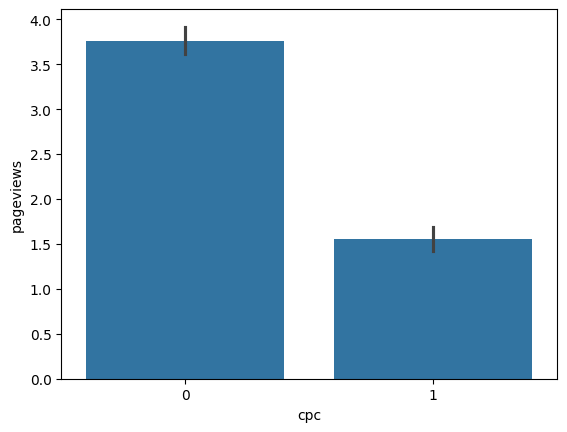

In [86]:
sns.barplot(x='cpc', y='pageviews', data=data)

#### Note: reading a barplot

**Breaking down `sns.barplot(x='cpc', y='pageviews', data=data)`:**
- `x='cpc'`: one bar per group: 0 = did not come via CPC, 1 = came via CPC
- `y='pageviews'`: the **height** of each bar is the **mean** of pageviews in that group (not the total, and not the number of visits)
- `data=data`: the dataframe the columns come from
- the black line on top of each bar is the **95% confidence interval** of that mean

**What is a confidence interval?**
Our data is a **sample** of visits, not every visit ever made. If we took another sample, the mean would come out slightly different. The 95% confidence interval is the range in which the **true mean** (the mean of all visits) most likely lies. More precisely: if we repeated the sampling many times, 95% of the intervals calculated this way would contain the true mean. Seaborn calculates it by *bootstrapping*: it resamples the data many times (1,000 by default) and looks at how much the mean varies.

The length of the line depends on two things:
- **how many cases** the group has: more cases, shorter line
- **how much the values vary**: more spread, longer line

**What you should see:**
- **CPC plot:** non-CPC visits have a mean of about 3.8 pages (interval roughly 3.6 to 3.9), CPC visits about 1.6 pages (roughly 1.4 to 1.7). Both lines are short (thousands of visits per group) and far apart, so we can be confident the difference is real.
- **Affiliate plot:** the affiliate bar (about 2.7 pages) has a much **longer** line, from roughly 2.1 to 3.4, because there are only 99 affiliate visits. It reaches close to the other bar (about 3.2), so this difference may be due to chance.

**Rule of thumb:** if the two intervals are far apart, the difference is very likely significant; if they overlap a lot, it is probably not. This is only a first impression: the regression is the formal test.


In [88]:
# Checking 
data.head(2)

,channelGrouping,date,device_browser,device_deviceCategory,device_isMobile,device_operatingSystem,fullVisitorId,geoNetwork_city,geoNetwork_continent,geoNetwork_country,...,trafficSource_referralPath,trafficSource_source,visitId,visitNumber,visitStartTime,pageviews,cpc,affiliate,apple_device,country_US
36548,Referral,20171010,Chrome,desktop,False,Macintosh,6413139757155395885,Austin,Americas,United States,...,/,(direct),1507650614,1,1507650614,3.0,0,0,1,1
26376,Display,20171007,Chrome,mobile,True,Android,1122408680230456408,NaN,Americas,United States,...,NaN,google,1507418877,1,1507418877,2.0,1,0,0,1


<Axes: xlabel='affiliate', ylabel='pageviews'>

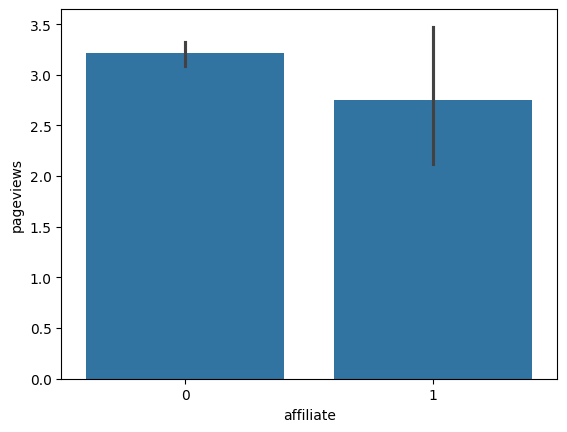

In [89]:
sns.barplot(x='affiliate', y='pageviews', data=data)

#### Note: what we expect from the model

**Why this step:** before running the model, we write down what the plots suggest. Afterwards we can check whether the model confirms it.

**What the plots suggest:**
- **CPC:** CPC visits view clearly fewer pages (about 1.6 against 3.8). The confidence intervals are short and far apart, so we expect a **significant negative** effect.
- **Affiliate:** affiliate visits view a little fewer pages (about 2.7 against 3.2), but the confidence interval is very long. That is because only **99 of the 7,846 visits** in our sample came via affiliate (see `value_counts()` above). With so few visits, the mean is uncertain, so we expect this difference may **not be significant**.

**What the model adds:** each plot looks at one variable at a time. The regression looks at all of them **together**: it estimates the effect of CPC and affiliate *while holding the controls (Apple device, US) constant*. For example, if CPC visits were mostly from outside the US, part of their lower pageviews could be a country effect. The model separates the two.


## Statistics: testing the hypotheses with OLS

We use OLS (linear regression) because our DV, `pageviews`, is a number. First we use it the "traditional" (frequentist) way: to test H1a and H1b.

In [91]:
ols_stat = sm.OLS(data['pageviews'], sm.add_constant(data[['cpc', 'affiliate', 'apple_device', 'country_US']]))

#### Note: building an OLS model in statsmodels

The barplots compare one variable at a time. A regression estimates the effect of each variable **while holding the others constant**, and tests whether it is significant.

**Breaking down `sm.OLS(data['pageviews'], sm.add_constant(data[[...]]))`:**
- first argument: the DV (y); second argument: the features (X).
- `sm.add_constant(...)` adds a column of 1s called `const`, so the model has an intercept (without it the line is forced through 0)
- this only *describes* the model; nothing is calculated yet

In [92]:
result_ols = ols_stat.fit()

In [93]:
result_ols

#### Note: estimating the model

**Breaking down `ols_stat.fit()`:**
- estimates the coefficients; `result_ols` stores everything (coefficients, p-values, ...), and `.summary()` prints it as a table

In [94]:
print(result_ols.summary())

                            OLS Regression Results                            
Dep. Variable:              pageviews   R-squared:                       0.052
Model:                            OLS   Adj. R-squared:                  0.052
Method:                 Least Squares   F-statistic:                     108.3
Date:                Fri, 02 Oct 2026   Prob (F-statistic):           5.58e-90
Time:                        13:39:00   Log-Likelihood:                -24120.
No. Observations:                7846   AIC:                         4.825e+04
Df Residuals:                    7841   BIC:                         4.829e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            3.0395      0.097     31.474   

#### Note: reading the OLS summary

Focus on these parts:

| Part | Read it as | Here |
|---|---|---|
| `const` | predicted pageviews when all features are 0 (non-campaign visitor, no Apple device, not in the US) | 3.04 pages |
| `coef` | change in pageviews when that feature goes from 0 to 1, holding the others constant | CPC: -2.57 pages |
| `R-squared` | share of the variation in pageviews the model explains | 0.052 (about 5%) |

A low R-squared is fine for testing hypotheses, but it means the model would not predict individual visits well.

## Machine Learning: predicting pageviews with the same model

Now we use the same model for the second goal: **predicting** how many pages a (new) visitor will view.

In [46]:
ols_clf = LinearRegression(fit_intercept = True)

In [95]:
ols_clf.fit(data[['cpc', 'affiliate', 'apple_device', 'country_US']], data['pageviews'])

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[-2.57,-0.67, 0.32, 1.49]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](4,)","['cpc','affiliate','apple_device','country_US']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,3.039
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,4


#### Note: the same model in sklearn

statsmodels answers "is there a significant effect?". For the second goal of this week, **predicting** pageviews for new visitors, we fit the same model in sklearn.

**Breaking down `LinearRegression(fit_intercept=True)` and `.fit(X, y)`:**
- `LinearRegression(...)` creates an **empty** model; `fit_intercept=True` does the job of `add_constant`
- `.fit(X, y)` estimates it. In sklearn the features come **first**: the opposite order of statsmodels

In [96]:
ols_clf.predict([[1,0,0,0]])

/Users/ednew/Library/jupyterlab-desktop/jlab_server/lib/python3.12/site-packages/sklearn/utils/validation.py:2830: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([0.46519194])

#### Note: predicting with `predict([[...]])`

**Breaking down `ols_clf.predict([[1,0,0,0]])`:**
- outer brackets = the list of visitors, inner brackets = one visitor
- the values follow the order of the features in `.fit`: `cpc, affiliate, apple_device, country_US`. So `[1,0,0,0]` is a CPC visitor without an Apple device, not in the US
- the result is an array with one prediction per visitor

In [97]:
ols_clf.predict([[0,1,0,0]])

/Users/ednew/Library/jupyterlab-desktop/jlab_server/lib/python3.12/site-packages/sklearn/utils/validation.py:2830: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([2.36652201])

In [98]:
ols_clf.predict([[0,0,0,0]])

/Users/ednew/Library/jupyterlab-desktop/jlab_server/lib/python3.12/site-packages/sklearn/utils/validation.py:2830: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([3.03945709])

In [99]:
ols_clf.predict([[0,0,1,0]])

/Users/ednew/Library/jupyterlab-desktop/jlab_server/lib/python3.12/site-packages/sklearn/utils/validation.py:2830: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([3.361564])

In [52]:
ols_clf.predict([[0,0,0,1]])

/Users/ednew/Library/jupyterlab-desktop/jlab_server/lib/python3.12/site-packages/sklearn/utils/validation.py:2830: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([4.53278452])

#### Note: where do the predictions come from?

The sklearn predictions are not new results: they are calculated from the **same coefficients** as in the OLS summary above. To predict a visitor, start from `const` (3.0395) and add the coefficient of every feature that is 1 for that visitor.

| Visitor | Input | Calculation | Prediction |
|---|---|---|---|
| non-campaign, no Apple, not US | `[[0,0,0,0]]` | 3.0395 (only `const`) | 3.039 |
| CPC | `[[1,0,0,0]]` | 3.0395 + (-2.5743) | 0.465 |
| affiliate | `[[0,1,0,0]]` | 3.0395 + (-0.6729) | 2.367 |
| Apple device | `[[0,0,1,0]]` | 3.0395 + 0.3221 | 3.362 |
| US | `[[0,0,0,1]]` | 3.0395 + 1.4933 | 4.533 |

So statsmodels and sklearn fit the **same model**; they are just used differently: statsmodels to **test** whether the coefficients are significant, sklearn to **predict** a value for a (new) visitor.


## Interpretation of the results

To decide whether a hypothesis is supported, we check two things in the OLS summary:

1. **Direction:** does the coefficient have the sign we expected? Our hypotheses expect **more** pages, so we need a **positive** coefficient.
2. **Significance:** is the p-value below 0.05? If not, the difference could be due to chance.

A hypothesis is supported only if **both** checks pass.

| Hypothesis | We expected | Coefficient | p-value | Verdict |
|---|---|---|---|---|
| *H1a.* Affiliate visitors view more pages than non-campaign visitors | positive | -0.67 | 0.206 | **not supported** |
| *H1b.* CPC visitors view more pages than non-campaign visitors | positive | -2.57 | < 0.001 | **not supported** |

**H1a (affiliate):** affiliate visitors view on average 0.67 pages *fewer* than non-campaign visitors. But the p-value (0.206) is above 0.05, so we cannot be sure this difference is real: with only 99 affiliate visits, it could be chance. In plain words: **we found no evidence that the affiliate campaign changes how many pages people view.**

**H1b (CPC):** CPC visitors view on average 2.57 pages *fewer* than non-campaign visitors, and the p-value is very small, so this difference is real. But it goes in the **opposite** direction from what we expected. In plain words: **the CPC campaign brings visitors who look at fewer pages, not more.** The predictions show the same: a CPC visitor is predicted to view 0.47 pages, a non-campaign visitor 3.04 pages.

**The controls:** visitors with an Apple device view 0.32 pages more, and visitors from the US 1.49 pages more; both are significant.

**How good is the model?** R-squared is 0.052: the four variables explain only about 5% of why some visits have more pages than others. That is fine for testing our hypotheses, but most of what drives pageviews is not in this model.

## Summary

| | Statistics (`statsmodels`) | Machine Learning (`sklearn`) |
|---|---|---|
| Goal | **test** the hypotheses | **predict** pageviews for a visitor |
| Code | `sm.OLS(y, sm.add_constant(X)).fit()` | `LinearRegression(fit_intercept=True).fit(X, y)` |
| Order of y and X | y first | X first |
| What we look at | coefficients and p-values in `.summary()` | `.predict([[...]])` |
| Result in this example | CPC: -2.57 pages (significant); affiliate: -0.67 (not significant) | CPC visitor: 0.47 pages; non-campaign visitor: 3.04 pages |

Both give the same numbers because they estimate the **same model**: a prediction is `const` plus the coefficients of the features that are 1.

In [108]:
# !ls ..

## Try this 

Engagement also means that visitors do **not** leave the website on the first page (a *bounce*). Repeat the example with this new DV:

* *H2a.* Users entering the website via the affiliate campaign will be less likely to leave the website on the first page (bounce) compared to users entering from non-campaign referrals.
* *H2b.* Users entering the website via the CPC campaign will be less likely to leave the website on the first page (bounce) compared to users entering from non-campaign referrals.

What changes compared with pageviews:

| | Pageviews (example above) | Bounce (your turn) |
|---|---|---|
| DV | `pageviews`: a number | `isExit`: 0/1 |
| Statistics | `sm.OLS` | `sm.Logit` |
| Machine Learning | `LinearRegression` | `LogisticRegression` |
| Prediction | `.predict()`: a number of pages | `.predict_proba()`: a probability of bouncing |

Replace `YOUR_ANSWER` in the cells below. The IVs and controls stay the same.

**Step 1: build the DV.** `landing_isExit` is `True` when the visitor left on the first page and empty (`NaN`) when they did not. Turn it into a 0/1 column.

In [102]:
def fix_landing(landing):
    # a missing value becomes the text 'nan': the visitor did NOT leave -> 0
    if str(landing).lower() == 'nan':
        return 0
    return 1

# hint: apply the function to the column landing_isExit
data['isExit'] = data['landing_isExit'].apply(YOUR_ANSWER)
data['isExit'].value_counts()

isExit
1    4591
0    3255
Name: count, dtype: int64

**Step 2: explore.** Compare the share of bounces between the groups. For a 0/1 variable, the height of the bar is the share of 1s (0.85 = 85% bounce).

<Axes: xlabel='cpc', ylabel='isExit'>

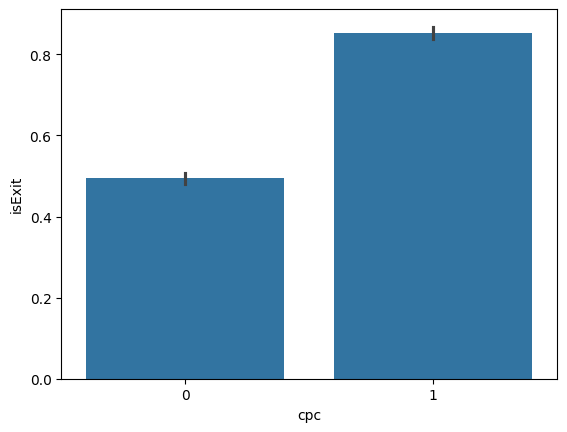

In [104]:
# hint: same as the pageviews barplots, with isExit as y
sns.barplot(x='cpc', y=YOUR_ANSWER, data=data)

**Step 3: statistics.** Because `isExit` is 0/1, use logistic regression. The structure is the same as `sm.OLS`.

Reading the summary: the coefficients are in **log-odds**, which are hard to put into words. Read only the **sign** (more or less likely to bounce) and the **p-value**.

In [107]:
# hint: sm.Logit(DV, sm.add_constant(features))
logit_stats = sm.Logit(YOUR_ANSWER, sm.add_constant(data[['cpc', 'affiliate', 'apple_device', 'country_US']]))
result_logit = logit_stats.fit()
print(result_logit.summary())

Optimization terminated successfully.
         Current function value: 0.604553
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                 isExit   No. Observations:                 7846
Model:                          Logit   Df Residuals:                     7841
Method:                           MLE   Df Model:                            4
Date:                Fri, 02 Oct 2026   Pseudo R-squ.:                  0.1091
Time:                        13:48:16   Log-Likelihood:                -4743.3
converged:                       True   LL-Null:                       -5324.1
Covariance Type:            nonrobust   LLR p-value:                3.333e-250
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const            0.3940      0.039     10.214      0.000       0.318       0.470
cpc              2.0023

**Step 4: Machine Learning.** Fit the same model in sklearn and predict the probability of bouncing. `predict_proba` returns **two** numbers per visitor: the probability of **not** bouncing and of **bouncing**.

In [ ]:
logit_clf = LogisticRegression(max_iter=1000, fit_intercept=True)

# hint: features first, then the DV (as for LinearRegression)
logit_clf.fit(data[['cpc', 'affiliate', 'apple_device', 'country_US']], YOUR_ANSWER)

# a CPC visitor, no Apple device, not in the US
logit_clf.predict_proba([[1, 0, 0, 0]])

**Step 5: interpret.** Are H2a and H2b supported? Use the sign and p-value of `cpc` and `affiliate` from Step 3, and the probabilities from Step 4.